# Brownlow 2025 Prediction
- Created by Jay Stein
- 3/9/22
- Purpose of this notebook is to make some awesome predictions for the upcoming Brownlow Medal

# Imports

## Standard Imports

In [1]:
import pandas as pd
import numpy as np

In [2]:
pd.set_option('display.max_rows', 500)
pd.set_option('display.max_columns', 500)
pd.set_option('display.width', 1000)
pd.options.mode.chained_assignment = None

In [3]:
import matplotlib.pyplot as plt
%matplotlib inline
plt.style.use('ggplot')

## Imports for XGBoost

In [4]:
# from sklearnex import patch_sklearn
# patch_sklearn()
from sklearn.model_selection import RandomizedSearchCV, GridSearchCV
from sklearn.model_selection import KFold
from xgboost import XGBRegressor
import xgboost as xgb
import shap

c:\Users\mrjay\miniconda3\envs\ds_std\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


# Read in data
- Got this using that super R library `fitzRoy`

In [5]:
#data from afl table
afltable = pd.read_csv(r"C:\Users\mrjay\python\jupyter_notebooks\Projects\brownlow\data\player_stats_2018_2025_fitzroy.csv", index_col=0)

C:\Users\mrjay\AppData\Local\Temp\ipykernel_37460\1989076876.py:2: DtypeWarning: Columns (50) have mixed types. Specify dtype option on import or set low_memory=False.
  afltable = pd.read_csv(r"C:\Users\mrjay\python\jupyter_notebooks\Projects\brownlow\data\player_stats_2018_2025_fitzroy.csv", index_col=0)


In [6]:
team_stats = pd.read_csv(r"C:\Users\mrjay\python\jupyter_notebooks\Projects\brownlow\data\team_stats_2018_2025_fitzroy.csv", index_col=0)

In [7]:
# read in Brownlow vote info
brownlow_votes = pd.read_csv(r"C:\Users\mrjay\python\jupyter_notebooks\Projects\brownlow\data\brownlow_stats_2018_2024_fitzroy.csv",
                             usecols=['Date','First.name','Surname','Playing.for','Brownlow.Votes'])
brownlow_votes['Date'] = pd.to_datetime(brownlow_votes['Date']).dt.date

## Data Normalization

In [8]:
def normal_cols(df):
    df.columns = df.columns.str.upper()
    df.columns = df.columns.str.replace(".","_")
    return df

In [9]:
afltable = normal_cols(afltable)
team_stats = normal_cols(team_stats)
brownlow_votes = normal_cols(brownlow_votes)

In [10]:
# get date of game
timeseries_utc = pd.to_datetime(afltable['UTCSTARTTIME'], utc=True)
local_dates = (timeseries_utc + pd.Timedelta(hours=10)).dt.date
afltable['GAME_DATE'] = local_dates

## Ensure no final rounds

In [11]:
afltable_filtered = afltable[~afltable['ROUND_NAME'].str.contains('Final')]

In [12]:
# add in full name for player
afltable_filtered['FULL_NAME'] = (afltable_filtered['PLAYER_GIVENNAME'] + ' ' + afltable_filtered['PLAYER_SURNAME']).str.upper()
brownlow_votes['FULL_NAME'] = (brownlow_votes['FIRST_NAME'] + ' ' + brownlow_votes['SURNAME']).str.upper()

In [13]:
afltable_filtered

,PROVIDERID,UTCSTARTTIME,STATUS,COMPSEASON_SHORTNAME,ROUND_NAME,ROUND_ROUNDNUMBER,VENUE_NAME,HOME_TEAM_NAME,HOME_TEAM_CLUB_NAME,AWAY_TEAM_NAME,AWAY_TEAM_CLUB_NAME,PLAYER_JUMPERNUMBER,PLAYER_PHOTOURL,PLAYER_PLAYER_POSITION,PLAYER_PLAYER_PLAYER_PLAYERID,PLAYER_PLAYER_PLAYER_CAPTAIN,PLAYER_PLAYER_PLAYER_PLAYERJUMPERNUMBER,PLAYER_PLAYER_PLAYER_GIVENNAME,PLAYER_PLAYER_PLAYER_SURNAME,TEAMID,GAMESPLAYED,TIMEONGROUNDPERCENTAGE,GOALS,BEHINDS,SUPERGOALS,KICKS,HANDBALLS,DISPOSALS,MARKS,BOUNCES,TACKLES,CONTESTEDPOSSESSIONS,UNCONTESTEDPOSSESSIONS,TOTALPOSSESSIONS,INSIDE50S,MARKSINSIDE50,CONTESTEDMARKS,HITOUTS,ONEPERCENTERS,DISPOSALEFFICIENCY,CLANGERS,FREESFOR,FREESAGAINST,DREAMTEAMPOINTS,REBOUND50S,GOALASSISTS,GOALACCURACY,RATINGPOINTS,RANKING,LASTUPDATED,TURNOVERS,INTERCEPTS,TACKLESINSIDE50,SHOTSATGOAL,GOALEFFICIENCY,SHOTEFFICIENCY,INTERCHANGECOUNTS,SCOREINVOLVEMENTS,METRESGAINED,CLEARANCES_CENTRECLEARANCES,CLEARANCES_STOPPAGECLEARANCES,CLEARANCES_TOTALCLEARANCES,EXTENDEDSTATS_EFFECTIVEKICKS,EXTENDEDSTATS_KICKEFFICIENCY,EXTENDEDSTATS_KICKTOHANDBALLRATIO,EXTENDEDSTATS_EFFECTIVEDISPOSALS,EXTENDEDSTATS_MARKSONLEAD,EXTENDEDSTATS_INTERCEPTMARKS,EXTENDEDSTATS_CONTESTEDPOSSESSIONRATE,EXTENDEDSTATS_HITOUTSTOADVANTAGE,EXTENDEDSTATS_HITOUTWINPERCENTAGE,EXTENDEDSTATS_HITOUTTOADVANTAGERATE,EXTENDEDSTATS_GROUNDBALLGETS,EXTENDEDSTATS_F50GROUNDBALLGETS,EXTENDEDSTATS_SCORELAUNCHES,EXTENDEDSTATS_PRESSUREACTS,EXTENDEDSTATS_DEFHALFPRESSUREACTS,EXTENDEDSTATS_SPOILS,EXTENDEDSTATS_RUCKCONTESTS,EXTENDEDSTATS_CONTESTDEFONEONONES,EXTENDEDSTATS_CONTESTDEFLOSSES,EXTENDEDSTATS_CONTESTDEFLOSSPERCENTAGE,EXTENDEDSTATS_CONTESTOFFONEONONES,EXTENDEDSTATS_CONTESTOFFWINS,EXTENDEDSTATS_CONTESTOFFWINSPERCENTAGE,EXTENDEDSTATS_CENTREBOUNCEATTENDANCES,EXTENDEDSTATS_KICKINS,EXTENDEDSTATS_KICKINSPLAYON,PLAYER_PLAYERID,PLAYER_CAPTAIN,PLAYER_PLAYERJUMPERNUMBER,PLAYER_GIVENNAME,PLAYER_SURNAME,TEAMSTATUS,EXTENDEDSTATS,TEAM_NAME,GAME_DATE,FULL_NAME
1,CD_M20250140002,2025-03-07T08:40:00.000+0000,CONCLUDED,Premiership,Opening Round,0,SCG,Sydney Swans,Sydney Swans,Hawthorn,Hawthorn,3,https://s.afl.com.au/staticfile/AFL Tenant/AFL...,INT,CD_I291776,False,3,Taylor,Adams,CD_T160,NaN,54,1,0,NaN,4,4,8,3,0,0,3,6,9,2,1,0,0,0,75.0,3,0,1,32,0,1,100.0,3.4,NaN,NaN,4,0,0,1,NaN,NaN,NaN,2,106,0,1,1,3.0,75.0,1.0,6.0,2.0,0.0,33.3,0.0,0.0,0.0,3.0,1.0,0.0,7.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,CD_I291776,False,3,Taylor,Adams,home,NaN,Sydney Swans,2025-03-07,TAYLOR ADAMS
2,CD_M20250140002,2025-03-07T08:40:00.000+0000,CONCLUDED,Premiership,Opening Round,0,SCG,Sydney Swans,Sydney Swans,Hawthorn,Hawthorn,36,https://s.afl.com.au/staticfile/AFL Tenant/AFL...,FF,CD_I1008091,False,36,Joel,Amartey,CD_T160,NaN,82,3,1,NaN,7,4,11,4,0,2,5,6,11,0,1,0,1,1,72.7,0,2,0,71,0,0,75.0,11.8,NaN,NaN,1,2,1,4,NaN,NaN,NaN,5,229,0,0,0,5.0,71.4,1.8,8.0,1.0,1.0,45.5,0.0,16.7,0.0,3.0,0.0,0.0,8.0,4.0,1.0,6.0,0.0,0.0,0.0,2.0,0.0,0.0,4.0,0.0,0.0,CD_I1008091,False,36,Joel,Amartey,home,NaN,Sydney Swans,2025-03-07,JOEL AMARTEY
3,CD_M20250140002,2025-03-07T08:40:00.000+0000,CONCLUDED,Premiership,Opening Round,0,SCG,Sydney Swans,Sydney Swans,Hawthorn,Hawthorn,22,https://s.afl.com.au/staticfile/AFL Tenant/AFL...,BPL,CD_I1006028,False,22,Nick,Blakey,CD_T160,NaN,87,1,0,NaN,21,5,26,3,4,0,6,9,15,1,0,0,0,6,80.8,4,2,0,90,13,0,100.0,22.4,NaN,NaN,4,8,0,1,NaN,NaN,NaN,3,804,0,0,0,16.0,76.2,4.2,21.0,0.0,1.0,40.0,0.0,0.0,0.0,4.0,0.0,1.0,1.0,1.0,6.0,0.0,4.0,0.0,0.0,0.0,0.0,0.0,0.0,10.0,10.0,CD_I1006028,False,22,Nick,Blakey,home,NaN,Sydney Swans,2025-03-07,NICK BLAKEY
4,CD_M20250140002,2025-03-07T08:40:00.000+0000,CONCLUDED,Premiership,Opening Round,0,SCG,Sydney Swans,Sydney Swans,Hawthorn,Hawthorn,16,https://s.afl.com.au/staticfile/AFL Tenant/AFL...,HFFL,CD_I1013133,False,16,Braeden,Campbell,CD_T160,NaN,80,0,0,NaN,6,2,8,2,0,4,2,5,7,4,0,0,0,1,87.5,0,0,0,44,1,1,0.0,9.6,NaN,NaN,2,0,0,0,NaN,NaN,NaN,3,225,0,0,0,5.0,83.3,3.0,7.0,0.0,0.0,28.6,0.0,0.0,0.0,2.0,0.0,0.0,17.0,9.0,0.0,0.0,0.0,0.0,0.0,2.0,0.0,0.0,1.0,0.0,0.0,CD_I1013133,False,16,Braeden,Campb

## Check columns with NaN

In [14]:
nan_threshold = 0.05 # set threshold at 5%
afltable_filtered_nan = afltable_filtered.isna().mean().sort_values(ascending=False).to_frame('nan_pct')
nan_cols = afltable_filtered_nan.query("nan_pct > @nan_threshold").index.tolist()
print(f"The following columns will be dropped: {nan_cols}")

The following columns will be dropped: ['SUPERGOALS', 'INTERCHANGECOUNTS', 'RANKING', 'GAMESPLAYED', 'EXTENDEDSTATS', 'GOALEFFICIENCY', 'SHOTEFFICIENCY', 'LASTUPDATED', 'EXTENDEDSTATS_KICKINS', 'EXTENDEDSTATS_KICKINSPLAYON', 'EXTENDEDSTATS_CENTREBOUNCEATTENDANCES']


In [15]:
afltable_filtered = afltable_filtered.drop(columns=nan_cols)

## Minimal feature engineering

In [16]:
afltable_filtered = afltable_filtered.assign(PLAYER_POINTS = lambda x: x['GOALS']*6 + x['BEHINDS'])

# Combine Player with Team Statistics

In [17]:
team_cols_to_keep = ['MATCHID','ROUND_YEAR','HOMETEAMSCORE_MINUTESINFRONT','AWAYTEAMSCORE_MINUTESINFRONT','HOMETEAMSCORE_MATCHSCORE_TOTALSCORE','AWAYTEAMSCORE_MATCHSCORE_TOTALSCORE']
team_stats_subset = team_stats.loc[:,team_cols_to_keep]

In [18]:
afltable_cols_to_keep = ['PROVIDERID','ROUND_ROUNDNUMBER','HOME_TEAM_NAME','PLAYER_PLAYER_POSITION','PLAYER_PLAYER_PLAYER_PLAYERID', 'GOALS','BEHINDS','KICKS','HANDBALLS','DISPOSALS','MARKS','BOUNCES','TACKLES','CONTESTEDPOSSESSIONS','UNCONTESTEDPOSSESSIONS',
                         'TOTALPOSSESSIONS','INSIDE50S','MARKSINSIDE50','CONTESTEDMARKS','HITOUTS','ONEPERCENTERS','DISPOSALEFFICIENCY','CLANGERS','FREESFOR','FREESAGAINST','DREAMTEAMPOINTS','REBOUND50S','GOALASSISTS','GOALACCURACY',
                         'RATINGPOINTS','TURNOVERS','INTERCEPTS','TACKLESINSIDE50','SHOTSATGOAL','SCOREINVOLVEMENTS','METRESGAINED','CLEARANCES_CENTRECLEARANCES','CLEARANCES_STOPPAGECLEARANCES','CLEARANCES_TOTALCLEARANCES',
                         'EXTENDEDSTATS_EFFECTIVEKICKS','EXTENDEDSTATS_KICKEFFICIENCY','EXTENDEDSTATS_KICKTOHANDBALLRATIO','EXTENDEDSTATS_EFFECTIVEDISPOSALS','EXTENDEDSTATS_MARKSONLEAD','EXTENDEDSTATS_INTERCEPTMARKS',
                         'EXTENDEDSTATS_CONTESTEDPOSSESSIONRATE','EXTENDEDSTATS_HITOUTSTOADVANTAGE','EXTENDEDSTATS_HITOUTWINPERCENTAGE','EXTENDEDSTATS_HITOUTTOADVANTAGERATE','EXTENDEDSTATS_GROUNDBALLGETS','EXTENDEDSTATS_F50GROUNDBALLGETS',
                         'EXTENDEDSTATS_SCORELAUNCHES','EXTENDEDSTATS_PRESSUREACTS','EXTENDEDSTATS_DEFHALFPRESSUREACTS','EXTENDEDSTATS_SPOILS','EXTENDEDSTATS_RUCKCONTESTS','EXTENDEDSTATS_CONTESTDEFONEONONES','EXTENDEDSTATS_CONTESTDEFLOSSES',
                         'EXTENDEDSTATS_CONTESTDEFLOSSPERCENTAGE','EXTENDEDSTATS_CONTESTOFFONEONONES','EXTENDEDSTATS_CONTESTOFFWINS','EXTENDEDSTATS_CONTESTOFFWINSPERCENTAGE','TEAM_NAME','FULL_NAME','PLAYER_POINTS','PLAYER_CAPTAIN','GAME_DATE']

In [19]:
afltable_subset = afltable_filtered.loc[:,afltable_cols_to_keep]

In [20]:
merged_df = afltable_subset.merge(team_stats_subset, how='inner', left_on='PROVIDERID', right_on='MATCHID')

# add in brownlow votes
merged_df = merged_df.merge(brownlow_votes, how='left', left_on=['GAME_DATE','FULL_NAME'], right_on=['DATE','FULL_NAME'])

In [21]:
# check it is working
merged_df.query("ROUND_YEAR == 2024").groupby(['FULL_NAME'])['BROWNLOW_VOTES'].sum().sort_values(ascending=False).head(5)

FULL_NAME
PATRICK CRIPPS    45.0
NICK DAICOS       38.0
ZAK BUTTERS       29.0
ISAAC HEENEY      28.0
CALEB SERONG      28.0
Name: BROWNLOW_VOTES, dtype: float64

## More minimal feature engineering

In [22]:
merged_df = (merged_df.
             assign(AT_HOME = lambda x: (x["HOME_TEAM_NAME"] == x["TEAM_NAME"]).astype(int),
                    PLAYERTEAMSCORE = lambda x: np.where(x['AT_HOME'] == 1, x['HOMETEAMSCORE_MATCHSCORE_TOTALSCORE'], x['AWAYTEAMSCORE_MATCHSCORE_TOTALSCORE']),
                    PLAYER_MINUTESINFRONT = lambda x: np.where(x['AT_HOME'] == 1, x['HOMETEAMSCORE_MINUTESINFRONT'], x['AWAYTEAMSCORE_MINUTESINFRONT']),
                    PLAYERTEAM_MARGIN = lambda x: np.where(x['AT_HOME'] == 1, 
                                                           x['HOMETEAMSCORE_MATCHSCORE_TOTALSCORE'] -  x['AWAYTEAMSCORE_MATCHSCORE_TOTALSCORE'],
                                                           x['AWAYTEAMSCORE_MATCHSCORE_TOTALSCORE'] -  x['HOMETEAMSCORE_MATCHSCORE_TOTALSCORE']
                                                           ),
                    PLAYERTEAM_OUTCOME = lambda x: np.where(
                        x['PLAYERTEAM_MARGIN'] > 0, 'WIN',
                        np.where(x['PLAYERTEAM_MARGIN'] == 0, 'DRAW','LOSE'))           
             ))

In [23]:
merged_df.sample(n=5).T.to_clipboard()

In [24]:
#merged_df[(merged_df["FULL_NAME"].str.contains('AMARTE')) & (merged_df['ROUND_YEAR'] == 2024) ]

## Add in team proportions

In [25]:
proportion_features = ['GOALS','BEHINDS','KICKS','HANDBALLS','DISPOSALS','MARKS','BOUNCES','TACKLES','CONTESTEDPOSSESSIONS','UNCONTESTEDPOSSESSIONS','TOTALPOSSESSIONS','INSIDE50S','MARKSINSIDE50',
                       'CONTESTEDMARKS','HITOUTS','ONEPERCENTERS','DISPOSALEFFICIENCY','CLANGERS','FREESFOR','FREESAGAINST','DREAMTEAMPOINTS','REBOUND50S','GOALASSISTS','GOALACCURACY','RATINGPOINTS',
                       'TURNOVERS','INTERCEPTS','TACKLESINSIDE50','SHOTSATGOAL','SCOREINVOLVEMENTS','METRESGAINED','CLEARANCES_CENTRECLEARANCES','CLEARANCES_STOPPAGECLEARANCES','CLEARANCES_TOTALCLEARANCES',
                       'EXTENDEDSTATS_EFFECTIVEKICKS','EXTENDEDSTATS_EFFECTIVEDISPOSALS','EXTENDEDSTATS_MARKSONLEAD','EXTENDEDSTATS_INTERCEPTMARKS','EXTENDEDSTATS_CONTESTEDPOSSESSIONRATE',
                       'EXTENDEDSTATS_HITOUTSTOADVANTAGE','EXTENDEDSTATS_HITOUTWINPERCENTAGE','EXTENDEDSTATS_HITOUTTOADVANTAGERATE','EXTENDEDSTATS_GROUNDBALLGETS','EXTENDEDSTATS_F50GROUNDBALLGETS',
                       'EXTENDEDSTATS_SCORELAUNCHES','EXTENDEDSTATS_PRESSUREACTS','EXTENDEDSTATS_DEFHALFPRESSUREACTS','EXTENDEDSTATS_SPOILS','EXTENDEDSTATS_RUCKCONTESTS','EXTENDEDSTATS_CONTESTDEFONEONONES',
                       'EXTENDEDSTATS_CONTESTDEFLOSSES','EXTENDEDSTATS_CONTESTDEFLOSSPERCENTAGE','EXTENDEDSTATS_CONTESTOFFONEONONES','EXTENDEDSTATS_CONTESTOFFWINS','EXTENDEDSTATS_CONTESTOFFWINSPERCENTAGE']

In [26]:
proportion_values = merged_df.groupby(['PROVIDERID','TEAM_NAME'])[proportion_features].transform(lambda x: x/x.sum())
proportion_values = proportion_values.fillna(0) #fill in NaN

In [27]:
proportion_labels = [col + "_prop" for col in proportion_values.columns] #make some nice labels
proportion_values.columns = proportion_labels #assign new labels

In [28]:
afltable_merged = pd.concat([merged_df, proportion_values], axis=1)

In [29]:
afltable_merged.head()

,PROVIDERID,ROUND_ROUNDNUMBER,HOME_TEAM_NAME,PLAYER_PLAYER_POSITION,PLAYER_PLAYER_PLAYER_PLAYERID,GOALS,BEHINDS,KICKS,HANDBALLS,DISPOSALS,MARKS,BOUNCES,TACKLES,CONTESTEDPOSSESSIONS,UNCONTESTEDPOSSESSIONS,TOTALPOSSESSIONS,INSIDE50S,MARKSINSIDE50,CONTESTEDMARKS,HITOUTS,ONEPERCENTERS,DISPOSALEFFICIENCY,CLANGERS,FREESFOR,FREESAGAINST,DREAMTEAMPOINTS,REBOUND50S,GOALASSISTS,GOALACCURACY,RATINGPOINTS,TURNOVERS,INTERCEPTS,TACKLESINSIDE50,SHOTSATGOAL,SCOREINVOLVEMENTS,METRESGAINED,CLEARANCES_CENTRECLEARANCES,CLEARANCES_STOPPAGECLEARANCES,CLEARANCES_TOTALCLEARANCES,EXTENDEDSTATS_EFFECTIVEKICKS,EXTENDEDSTATS_KICKEFFICIENCY,EXTENDEDSTATS_KICKTOHANDBALLRATIO,EXTENDEDSTATS_EFFECTIVEDISPOSALS,EXTENDEDSTATS_MARKSONLEAD,EXTENDEDSTATS_INTERCEPTMARKS,EXTENDEDSTATS_CONTESTEDPOSSESSIONRATE,EXTENDEDSTATS_HITOUTSTOADVANTAGE,EXTENDEDSTATS_HITOUTWINPERCENTAGE,EXTENDEDSTATS_HITOUTTOADVANTAGERATE,EXTENDEDSTATS_GROUNDBALLGETS,EXTENDEDSTATS_F50GROUNDBALLGETS,EXTENDEDSTATS_SCORELAUNCHES,EXTENDEDSTATS_PRESSUREACTS,EXTENDEDSTATS_DEFHALFPRESSUREACTS,EXTENDEDSTATS_SPOILS,EXTENDEDSTATS_RUCKCONTESTS,EXTENDEDSTATS_CONTESTDEFONEONONES,EXTENDEDSTATS_CONTESTDEFLOSSES,EXTENDEDSTATS_CONTESTDEFLOSSPERCENTAGE,EXTENDEDSTATS_CONTESTOFFONEONONES,EXTENDEDSTATS_CONTESTOFFWINS,EXTENDEDSTATS_CONTESTOFFWINSPERCENTAGE,TEAM_NAME,FULL_NAME,PLAYER_POINTS,PLAYER_CAPTAIN,GAME_DATE,MATCHID,ROUND_YEAR,HOMETEAMSCORE_MINUTESINFRONT,AWAYTEAMSCORE_MINUTESINFRONT,HOMETEAMSCORE_MATCHSCORE_TOTALSCORE,AWAYTEAMSCORE_MATCHSCORE_TOTALSCORE,DATE,FIRST_NAME,SURNAME,PLAYING_FOR,BROWNLOW_VOTES,AT_HOME,PLAYERTEAMSCORE,PLAYER_MINUTESINFRONT,PLAYERTEAM_MARGIN,PLAYERTEAM_OUTCOME,GOALS_prop,BEHINDS_prop,KICKS_prop,HANDBALLS_prop,DISPOSALS_prop,MARKS_prop,BOUNCES_prop,TACKLES_prop,CONTESTEDPOSSESSIONS_prop,UNCONTESTEDPOSSESSIONS_prop,TOTALPOSSESSIONS_prop,INSIDE50S_prop,MARKSINSIDE50_prop,CONTESTEDMARKS_prop,HITOUTS_prop,ONEPERCENTERS_prop,DISPOSALEFFICIENCY_prop,CLANGERS_prop,FREESFOR_prop,FREESAGAINST_prop,DREAMTEAMPOINTS_prop,REBOUND50S_prop,GOALASSISTS_prop,GOALACCURACY_prop,RATINGPOINTS_prop,TURNOVERS_prop,INTERCEPTS_prop,TACKLESINSIDE50_prop,SHOTSATGOAL_prop,SCOREINVOLVEMENTS_prop,METRESGAINED_prop,CLEARANCES_CENTRECLEARANCES_prop,CLEARANCES_STOPPAGECLEARANCES_prop,CLEARANCES_TOTALCLEARANCES_prop,EXTENDEDSTATS_EFFECTIVEKICKS_prop,EXTENDEDSTATS_EFFECTIVEDISPOSALS_prop,EXTENDEDSTATS_MARKSONLEAD_prop,EXTENDEDSTATS_INTERCEPTMARKS_prop,EXTENDEDSTATS_CONTESTEDPOSSESSIONRATE_prop,EXTENDEDSTATS_HITOUTSTOADVANTAGE_prop,EXTENDEDSTATS_HITOUTWINPERCENTAGE_prop,EXTENDEDSTATS_HITOUTTOADVANTAGERATE_prop,EXTENDEDSTATS_GROUNDBALLGETS_prop,EXTENDEDSTATS_F50GROUNDBALLGETS_prop,EXTENDEDSTATS_SCORELAUNCHES_prop,EXTENDEDSTATS_PRESSUREACTS_prop,EXTENDEDSTATS_DEFHALFPRESSUREACTS_prop,EXTENDEDSTATS_SPOILS_prop,EXTENDEDSTATS_RUCKCONTESTS_prop,EXTENDEDSTATS_CONTESTDEFONEONONES_prop,EXTENDEDSTATS_CONTESTDEFLOSSES_prop,EXTENDEDSTATS_CONTESTDEFLOSSPERCENTAGE_prop,EXTENDEDSTATS_CONTESTOFFONEONONES_prop,EXTENDEDSTATS_CONTESTOFFWINS_prop,EXTENDEDSTATS_CONTESTOFFWINSPERCENTAGE_prop
0,CD_M20250140002,0,Sydney Swans,INT,CD_I291776,1,0,4,4,8,3,0,0,3,6,9,2,1,0,0,0,75.0,3,0,1,32,0,1,100.0,3.4,4,0,0,1,2,106,0,1,1,3.0,75.0,1.0,6.0,2.0,0.0,33.3,0.0,0.0,0.0,3.0,1.0,0.0,7.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,Sydney Swans,TAYLOR ADAMS,6,False,2025-03-07,CD_M20250140002,2025,15,112,76,96,NaN,NaN,NaN,NaN,NaN,1,76,15,-20,LOSE,0.090909,0.000000,0.019704,0.033898,0.024922,0.042254,0.000000,0.000000,0.024793,0.033333,0.029900,0.050,0.2,0.0,0.00000,0.000000,0.044757,0.050000,0.000000,0.043478,0.023881,0.000000,0.142857,0.16,0.019058,0.064516,0.000000,0.0,0.05,0.023529,0.019283,0.0,0.047619,0.030303,0.022222,0.025641,0.285714,0.000000,0.035516,0.0,0.000000,0.0,0.034884,0.083333,0.000000,0.026022,0.006494,0.000,0.000000,0.000000,0.0,0.0,0.000000,0.0,0.0
1,CD_M20250140002,0,Sydney Swans,FF,CD_I1008091,3,1,7,4,11,4,0,2,5,6,11,0,1,0,1,1,72.7,0,2,0,71,0,0,75.0,11.8,1,2,1,4,5,229,0,0,0,5.0,71.4,1.8,8.0,1.0,1.0,45.5,0.0,16.7,0.0,3.0,0.0,0.0,8.0,4.0,1.0,6.0,0

In [30]:
feature_list = ['PLAYER_PLAYER_POSITION','GOALS','BEHINDS','KICKS','HANDBALLS','DISPOSALS','MARKS','BOUNCES','TACKLES','CONTESTEDPOSSESSIONS','UNCONTESTEDPOSSESSIONS','TOTALPOSSESSIONS','INSIDE50S','MARKSINSIDE50','CONTESTEDMARKS',
                'HITOUTS','ONEPERCENTERS','DISPOSALEFFICIENCY','CLANGERS','FREESFOR','FREESAGAINST','DREAMTEAMPOINTS','REBOUND50S','GOALASSISTS','GOALACCURACY','RATINGPOINTS','TURNOVERS','INTERCEPTS','TACKLESINSIDE50','SHOTSATGOAL',
                'SCOREINVOLVEMENTS','METRESGAINED','CLEARANCES_CENTRECLEARANCES','CLEARANCES_STOPPAGECLEARANCES','CLEARANCES_TOTALCLEARANCES','EXTENDEDSTATS_EFFECTIVEKICKS','EXTENDEDSTATS_KICKEFFICIENCY','EXTENDEDSTATS_KICKTOHANDBALLRATIO',
                'EXTENDEDSTATS_EFFECTIVEDISPOSALS','EXTENDEDSTATS_MARKSONLEAD','EXTENDEDSTATS_INTERCEPTMARKS','EXTENDEDSTATS_CONTESTEDPOSSESSIONRATE','EXTENDEDSTATS_HITOUTSTOADVANTAGE','EXTENDEDSTATS_HITOUTWINPERCENTAGE',
                'EXTENDEDSTATS_HITOUTTOADVANTAGERATE','EXTENDEDSTATS_GROUNDBALLGETS','EXTENDEDSTATS_F50GROUNDBALLGETS','EXTENDEDSTATS_SCORELAUNCHES','EXTENDEDSTATS_PRESSUREACTS','EXTENDEDSTATS_DEFHALFPRESSUREACTS',
                'EXTENDEDSTATS_SPOILS','EXTENDEDSTATS_RUCKCONTESTS','EXTENDEDSTATS_CONTESTDEFONEONONES','EXTENDEDSTATS_CONTESTDEFLOSSES','EXTENDEDSTATS_CONTESTDEFLOSSPERCENTAGE','EXTENDEDSTATS_CONTESTOFFONEONONES',
                'EXTENDEDSTATS_CONTESTOFFWINS','EXTENDEDSTATS_CONTESTOFFWINSPERCENTAGE','PLAYER_POINTS','PLAYER_CAPTAIN','AT_HOME','PLAYERTEAMSCORE','PLAYER_MINUTESINFRONT','PLAYERTEAM_MARGIN','PLAYERTEAM_OUTCOME',
                'GOALS_prop','BEHINDS_prop','KICKS_prop','HANDBALLS_prop','DISPOSALS_prop','MARKS_prop','BOUNCES_prop','TACKLES_prop','CONTESTEDPOSSESSIONS_prop','UNCONTESTEDPOSSESSIONS_prop','TOTALPOSSESSIONS_prop',
                'INSIDE50S_prop','MARKSINSIDE50_prop','CONTESTEDMARKS_prop','HITOUTS_prop','ONEPERCENTERS_prop','DISPOSALEFFICIENCY_prop','CLANGERS_prop','FREESFOR_prop','FREESAGAINST_prop','DREAMTEAMPOINTS_prop',
                'REBOUND50S_prop','GOALASSISTS_prop','GOALACCURACY_prop','RATINGPOINTS_prop','TURNOVERS_prop','INTERCEPTS_prop','TACKLESINSIDE50_prop','SHOTSATGOAL_prop','SCOREINVOLVEMENTS_prop','METRESGAINED_prop',
                'CLEARANCES_CENTRECLEARANCES_prop','CLEARANCES_STOPPAGECLEARANCES_prop','CLEARANCES_TOTALCLEARANCES_prop','EXTENDEDSTATS_EFFECTIVEKICKS_prop','EXTENDEDSTATS_EFFECTIVEDISPOSALS_prop','EXTENDEDSTATS_MARKSONLEAD_prop',
                'EXTENDEDSTATS_INTERCEPTMARKS_prop','EXTENDEDSTATS_CONTESTEDPOSSESSIONRATE_prop','EXTENDEDSTATS_HITOUTSTOADVANTAGE_prop','EXTENDEDSTATS_HITOUTWINPERCENTAGE_prop','EXTENDEDSTATS_HITOUTTOADVANTAGERATE_prop',
                'EXTENDEDSTATS_GROUNDBALLGETS_prop','EXTENDEDSTATS_F50GROUNDBALLGETS_prop','EXTENDEDSTATS_SCORELAUNCHES_prop','EXTENDEDSTATS_PRESSUREACTS_prop','EXTENDEDSTATS_DEFHALFPRESSUREACTS_prop','EXTENDEDSTATS_SPOILS_prop',
                'EXTENDEDSTATS_RUCKCONTESTS_prop','EXTENDEDSTATS_CONTESTDEFONEONONES_prop','EXTENDEDSTATS_CONTESTDEFLOSSES_prop','EXTENDEDSTATS_CONTESTDEFLOSSPERCENTAGE_prop','EXTENDEDSTATS_CONTESTOFFONEONONES_prop',
                'EXTENDEDSTATS_CONTESTOFFWINS_prop','EXTENDEDSTATS_CONTESTOFFWINSPERCENTAGE_prop']

In [31]:
X_afl_all = afltable_merged.reset_index(drop=True)
y_afl_all = afltable_merged['BROWNLOW_VOTES'].reset_index(drop=True) #remember nothing yet assigned for 2025 season train on 2018-2024

## Create reference tables player id and game id

In [32]:
player_id = afltable_merged[['PLAYER_PLAYER_PLAYER_PLAYERID','FULL_NAME']].drop_duplicates().reset_index(drop=True) #retain for reference
player_id = player_id.rename(columns={'PLAYER_PLAYER_PLAYER_PLAYERID':'PLAYER_ID'})
player_id = player_id.set_index('PLAYER_ID')
player_id['PLAYER_ID'] = player_id.index

In [33]:
game_id_df = afltable_merged[['ROUND_YEAR','ROUND_ROUNDNUMBER','MATCHID']].drop_duplicates()
game_id_df = game_id_df.reset_index(drop=True)
game_id_df['GAME_ID'] = game_id_df.index

# Use all training data

In [34]:
X_afl_train = X_afl_all.query("ROUND_YEAR != 2025")
X_afl_test = X_afl_all.query("ROUND_YEAR == 2025")
y_afl_train = y_afl_all.loc[X_afl_train.index]

In [35]:
len(X_afl_train)

61462

In [36]:
len(y_afl_train)

61462

# Check if we have all the BROWNLOW VOTES
- for previous years

In [37]:
brownlow_total_check = afltable_merged.groupby(['FULL_NAME','TEAM_NAME','ROUND_YEAR'])['BROWNLOW_VOTES'].sum().unstack(['ROUND_YEAR'])

In [38]:
brownlow_total_check

ROUND_YEAR                       2018  2019  2020  2021  2022  2023  2024  2025
FULL_NAME     TEAM_NAME                                                        
AARON BLACK   Geelong Cats        0.0   NaN   NaN   NaN   NaN   NaN   NaN   NaN
              West Coast Eagles   NaN   NaN   NaN   NaN   0.0   NaN   NaN   NaN
AARON CADMAN  GWS GIANTS          NaN   NaN   NaN   NaN   NaN   0.0   0.0   0.0
AARON FRANCIS Essendon            0.0   0.0   0.0   0.0   0.0   NaN   NaN   NaN
              Sydney Swans        NaN   NaN   NaN   NaN   NaN   0.0   0.0   0.0
...                               ...   ...   ...   ...   ...   ...   ...   ...
ZAK JOHNSON   Essendon            NaN   NaN   NaN   NaN   NaN   NaN   NaN   0.0
ZAK JONES     St Kilda            NaN   NaN   7.0   4.0   0.0   0.0   1.0   0.0
              Sydney Swans        0.0   0.0   NaN   NaN   NaN   NaN   NaN   NaN
ZANE DUURSMA  North Melbourne     NaN   NaN   NaN   NaN   NaN   NaN   0.0   0.0
ZANE TREW     West Coast Eagles   NaN   NaN   NaN   NaN   0.0   0.0   0.0   NaN

[1594 rows x 8 columns]

In [39]:
years = [int(y) for y in range(2018, 2025)]
rows = []

for yr in years:
    s = brownlow_total_check[yr].nlargest(5)  # Series: index -> value, ignores NaN
    idxs = list(s.index)
    vals = list(s.values)
    # pad to length 5
    while len(idxs) < 5:
        idxs.append(pd.NA)
        vals.append(pd.NA)
    rows.append({
        'year': yr,
        'top1_name': idxs[0], 'top1_value': vals[0],
        'top2_name': idxs[1], 'top2_value': vals[1],
        'top3_name': idxs[2], 'top3_value': vals[2],
        'top4_name': idxs[3], 'top4_value': vals[3],
        'top5_name': idxs[4], 'top5_value': vals[4],
    })

top5_df = pd.DataFrame(rows).set_index('year')

In [40]:
top5_df

,top1_name,top1_value,top2_name,top2_value,top3_name,top3_value,top4_name,top4_value,top5_name,top5_value
year,,,,,,,,,,
2018,"(TOM MITCHELL, Hawthorn)",28.0,"(STEELE SIDEBOTTOM, Collingwood)",24.0,"(ANGUS BRAYSHAW, Melbourne)",21.0,"(MAX GAWN, Melbourne)",20.0,"(PATRICK CRIPPS, Carlton)",20.0
2019,"(NAT FYFE, Fremantle)",33.0,"(PATRICK DANGERFIELD, Geelong Cats)",27.0,"(LACHIE NEALE, Brisbane Lions)",26.0,"(PATRICK CRIPPS, Carlton)",26.0,"(TIM KELLY, Geelong Cats)",24.0
2020,"(LACHIE NEALE, Brisbane Lions)",31.0,"(TRAVIS BOAK, Port Adelaide)",21.0,"(CHRISTIAN PETRACCA, Melbourne)",20.0,"(JACK STEELE, St Kilda)",20.0,"(DUSTIN MARTIN, Richmond)",15.0
2021,"(OLLIE WINES, Port Adelaide)",36.0,"(MARCUS BONTEMPELLI, Western Bulldogs)",33.0,"(CLAYTON OLIVER, Melbourne)",31.0,"(SAM WALSH, Carlton)",30.0,"(DARCY PARISH, Essendon)",26.0
2022,"(PATRICK CRIPPS, Carlton)",29.0,"(LACHIE NEALE, Brisbane Lions)",28.0,"(TOUK MILLER, Gold Coast SUNS)",27.0,"(ANDREW BRAYSHAW, Fremantle)",25.0,"(CLAYTON OLIVER, Melbourne)",25.0
2023,"(LACHIE NEALE, Brisbane Lions)",31.0,"(MARCUS BONTEMPELLI, Western Bulldogs)",29.0,"(NICK DAICOS, Collingwood)",28.0,"(ERROL GULDEN, Sydney Swans)",27.0,"(ZAK BUTTERS, Port Adelaide)",27.0
2024,"(PATRICK CRIPPS, Carlton)",45.0,"(NICK DAICOS, Collingwood)",38.0,"(ZAK BUTTERS, Port Adelaide)",29.0,"(CALEB SERONG, Fremantle)",28.0,"(ISAAC HEENEY, Sydney Swans)",28.0


# Prepare for ML

In [41]:
# map the categorical cols
cat_cols = ['PLAYER_PLAYER_POSITION', 'PLAYERTEAM_OUTCOME']

In [42]:
for c in cat_cols:
    X_afl_train[c] = X_afl_train[c].astype('category')
    X_afl_test[c] = X_afl_test[c].astype('category')

In [43]:
# very small number of NaN..... we can just fill them with mean
X_afl_train[feature_list].isna().sum().sort_values(ascending=False)

EXTENDEDSTATS_KICKEFFICIENCY                   5
EXTENDEDSTATS_CONTESTDEFLOSSES                 5
EXTENDEDSTATS_RUCKCONTESTS                     5
EXTENDEDSTATS_SPOILS                           5
EXTENDEDSTATS_DEFHALFPRESSUREACTS              5
EXTENDEDSTATS_PRESSUREACTS                     5
RATINGPOINTS                                   5
EXTENDEDSTATS_SCORELAUNCHES                    5
EXTENDEDSTATS_F50GROUNDBALLGETS                5
EXTENDEDSTATS_GROUNDBALLGETS                   5
EXTENDEDSTATS_HITOUTTOADVANTAGERATE            5
EXTENDEDSTATS_HITOUTWINPERCENTAGE              5
EXTENDEDSTATS_HITOUTSTOADVANTAGE               5
EXTENDEDSTATS_CONTESTEDPOSSESSIONRATE          5
EXTENDEDSTATS_INTERCEPTMARKS                   5
EXTENDEDSTATS_MARKSONLEAD                      5
EXTENDEDSTATS_EFFECTIVEKICKS                   5
EXTENDEDSTATS_CONTESTDEFONEONONES              5
EXTENDEDSTATS_CONTESTDEFLOSSPERCENTAGE         5
EXTENDEDSTATS_KICKTOHANDBALLRATIO              5
EXTENDEDSTATS_CONTES

In [44]:
X_afl_test[feature_list].isna().sum().sort_values(ascending=False)

EXTENDEDSTATS_KICKEFFICIENCY                   7
EXTENDEDSTATS_CONTESTDEFLOSSES                 7
EXTENDEDSTATS_RUCKCONTESTS                     7
EXTENDEDSTATS_SPOILS                           7
EXTENDEDSTATS_DEFHALFPRESSUREACTS              7
EXTENDEDSTATS_PRESSUREACTS                     7
RATINGPOINTS                                   7
EXTENDEDSTATS_SCORELAUNCHES                    7
EXTENDEDSTATS_F50GROUNDBALLGETS                7
EXTENDEDSTATS_GROUNDBALLGETS                   7
EXTENDEDSTATS_HITOUTTOADVANTAGERATE            7
EXTENDEDSTATS_HITOUTWINPERCENTAGE              7
EXTENDEDSTATS_HITOUTSTOADVANTAGE               7
EXTENDEDSTATS_CONTESTEDPOSSESSIONRATE          7
EXTENDEDSTATS_INTERCEPTMARKS                   7
EXTENDEDSTATS_MARKSONLEAD                      7
EXTENDEDSTATS_EFFECTIVEKICKS                   7
EXTENDEDSTATS_CONTESTDEFONEONONES              7
EXTENDEDSTATS_CONTESTDEFLOSSPERCENTAGE         7
EXTENDEDSTATS_KICKTOHANDBALLRATIO              7
EXTENDEDSTATS_CONTES

In [45]:
X_afl_train[feature_list].shape

(61462, 120)

In [46]:
numeric_features = X_afl_train[feature_list].select_dtypes(include=['number']).columns.tolist()

In [47]:
numeric_features_means = X_afl_train[numeric_features].mean()
numeric_features_test_means = X_afl_test[numeric_features].mean()

In [48]:
len(numeric_features)

117

In [49]:
# fill in the NaN
X_afl_train[numeric_features] = X_afl_train[numeric_features].fillna(numeric_features_means)
X_afl_test[numeric_features] = X_afl_test[numeric_features].fillna(numeric_features_test_means)

In [50]:
X_afl_train[feature_list].isna().sum().sum()

0

In [51]:
# there are some null with brownlow votes - we can safely fill them with 0

In [52]:
y_afl_train.isna().sum().sum()

1879

In [53]:
y_afl_train = y_afl_train.fillna(0)

# Time for magic!

In [54]:
data_matrix = xgb.DMatrix(data=X_afl_train[feature_list], label=y_afl_train, enable_categorical=True)
params = {'verbosity':1, 'subsample': 0.8, 'colsample_bytree':0.8, #'n_estimators':1000,
         'learning_rate':0.10}

In [55]:
X_afl_train

,PROVIDERID,ROUND_ROUNDNUMBER,HOME_TEAM_NAME,PLAYER_PLAYER_POSITION,PLAYER_PLAYER_PLAYER_PLAYERID,GOALS,BEHINDS,KICKS,HANDBALLS,DISPOSALS,MARKS,BOUNCES,TACKLES,CONTESTEDPOSSESSIONS,UNCONTESTEDPOSSESSIONS,TOTALPOSSESSIONS,INSIDE50S,MARKSINSIDE50,CONTESTEDMARKS,HITOUTS,ONEPERCENTERS,DISPOSALEFFICIENCY,CLANGERS,FREESFOR,FREESAGAINST,DREAMTEAMPOINTS,REBOUND50S,GOALASSISTS,GOALACCURACY,RATINGPOINTS,TURNOVERS,INTERCEPTS,TACKLESINSIDE50,SHOTSATGOAL,SCOREINVOLVEMENTS,METRESGAINED,CLEARANCES_CENTRECLEARANCES,CLEARANCES_STOPPAGECLEARANCES,CLEARANCES_TOTALCLEARANCES,EXTENDEDSTATS_EFFECTIVEKICKS,EXTENDEDSTATS_KICKEFFICIENCY,EXTENDEDSTATS_KICKTOHANDBALLRATIO,EXTENDEDSTATS_EFFECTIVEDISPOSALS,EXTENDEDSTATS_MARKSONLEAD,EXTENDEDSTATS_INTERCEPTMARKS,EXTENDEDSTATS_CONTESTEDPOSSESSIONRATE,EXTENDEDSTATS_HITOUTSTOADVANTAGE,EXTENDEDSTATS_HITOUTWINPERCENTAGE,EXTENDEDSTATS_HITOUTTOADVANTAGERATE,EXTENDEDSTATS_GROUNDBALLGETS,EXTENDEDSTATS_F50GROUNDBALLGETS,EXTENDEDSTATS_SCORELAUNCHES,EXTENDEDSTATS_PRESSUREACTS,EXTENDEDSTATS_DEFHALFPRESSUREACTS,EXTENDEDSTATS_SPOILS,EXTENDEDSTATS_RUCKCONTESTS,EXTENDEDSTATS_CONTESTDEFONEONONES,EXTENDEDSTATS_CONTESTDEFLOSSES,EXTENDEDSTATS_CONTESTDEFLOSSPERCENTAGE,EXTENDEDSTATS_CONTESTOFFONEONONES,EXTENDEDSTATS_CONTESTOFFWINS,EXTENDEDSTATS_CONTESTOFFWINSPERCENTAGE,TEAM_NAME,FULL_NAME,PLAYER_POINTS,PLAYER_CAPTAIN,GAME_DATE,MATCHID,ROUND_YEAR,HOMETEAMSCORE_MINUTESINFRONT,AWAYTEAMSCORE_MINUTESINFRONT,HOMETEAMSCORE_MATCHSCORE_TOTALSCORE,AWAYTEAMSCORE_MATCHSCORE_TOTALSCORE,DATE,FIRST_NAME,SURNAME,PLAYING_FOR,BROWNLOW_VOTES,AT_HOME,PLAYERTEAMSCORE,PLAYER_MINUTESINFRONT,PLAYERTEAM_MARGIN,PLAYERTEAM_OUTCOME,GOALS_prop,BEHINDS_prop,KICKS_prop,HANDBALLS_prop,DISPOSALS_prop,MARKS_prop,BOUNCES_prop,TACKLES_prop,CONTESTEDPOSSESSIONS_prop,UNCONTESTEDPOSSESSIONS_prop,TOTALPOSSESSIONS_prop,INSIDE50S_prop,MARKSINSIDE50_prop,CONTESTEDMARKS_prop,HITOUTS_prop,ONEPERCENTERS_prop,DISPOSALEFFICIENCY_prop,CLANGERS_prop,FREESFOR_prop,FREESAGAINST_prop,DREAMTEAMPOINTS_prop,REBOUND50S_prop,GOALASSISTS_prop,GOALACCURACY_prop,RATINGPOINTS_prop,TURNOVERS_prop,INTERCEPTS_prop,TACKLESINSIDE50_prop,SHOTSATGOAL_prop,SCOREINVOLVEMENTS_prop,METRESGAINED_prop,CLEARANCES_CENTRECLEARANCES_prop,CLEARANCES_STOPPAGECLEARANCES_prop,CLEARANCES_TOTALCLEARANCES_prop,EXTENDEDSTATS_EFFECTIVEKICKS_prop,EXTENDEDSTATS_EFFECTIVEDISPOSALS_prop,EXTENDEDSTATS_MARKSONLEAD_prop,EXTENDEDSTATS_INTERCEPTMARKS_prop,EXTENDEDSTATS_CONTESTEDPOSSESSIONRATE_prop,EXTENDEDSTATS_HITOUTSTOADVANTAGE_prop,EXTENDEDSTATS_HITOUTWINPERCENTAGE_prop,EXTENDEDSTATS_HITOUTTOADVANTAGERATE_prop,EXTENDEDSTATS_GROUNDBALLGETS_prop,EXTENDEDSTATS_F50GROUNDBALLGETS_prop,EXTENDEDSTATS_SCORELAUNCHES_prop,EXTENDEDSTATS_PRESSUREACTS_prop,EXTENDEDSTATS_DEFHALFPRESSUREACTS_prop,EXTENDEDSTATS_SPOILS_prop,EXTENDEDSTATS_RUCKCONTESTS_prop,EXTENDEDSTATS_CONTESTDEFONEONONES_prop,EXTENDEDSTATS_CONTESTDEFLOSSES_prop,EXTENDEDSTATS_CONTESTDEFLOSSPERCENTAGE_prop,EXTENDEDSTATS_CONTESTOFFONEONONES_prop,EXTENDEDSTATS_CONTESTOFFWINS_prop,EXTENDEDSTATS_CONTESTOFFWINSPERCENTAGE_prop
9529,CD_M20240140001,0,Sydney Swans,HFFR,CD_I1008091,0,1,3,0,3,1,0,2,0,2,2,0,0,0,2,1,0.0,1,0,0,23,0,0,0.0,-2.1,2,0,1,1,1,79,0,0,0,0.0,0.0,3.0,0.0,0.0,0.0,0.0,0.0,50.0,0.0,0.0,0.0,0.0,5.0,2.0,1.0,4.0,0.0,0.0,0.0,0.0,0.0,0.0,Sydney Swans,JOEL AMARTEY,1,False,2024-03-07,CD_M20240140001,2024,100,13,86,64,2024-03-07,Joel,Amartey,Sydney,0.0,1,86,100,22,WIN,0.000000,0.100000,0.012821,0.000000,0.008403,0.010101,0.000000,0.031746,0.000000,0.009615,0.005650,0.000000,0.000000,0.000,0.043478,0.014925,0.000000,0.015873,0.000000,0.000000,0.014612,0.000000,0.0,0.000000,-0.009321,0.025641,0.000000,0.076923,0.034483,0.012195,0.012560,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.212675,0.0,0.000000,0.000000,0.000000,0.015291,0.012658,0.021277,0.038095,0.000000,0.000000,0.000000,0.000000,0.0,0.0
9530,CD_M20240140001,0,Sydney Swans,HBFL,CD_I1006028,0,0,18,8,26,9,6,0,6,16,22,6,0,1,0,6,69.2,2,2,0,99,7,2,0.0,15.6,3,6,0,0,4,530,0,0,0,13.0,72.2,2.3,18.0

In [56]:
from sklearn.model_selection import train_test_split

In [57]:
# 1) prepare a validation split (recommended)
X_train, X_val, y_train, y_val = train_test_split(
    X_afl_train[feature_list], y_afl_train, test_size=0.1, random_state=42
)

In [58]:
# 2) build DMatrix objects (enable_categorical=True if you used pandas categorical dtype)
dtrain = xgb.DMatrix(X_train, label=y_train, enable_categorical=True)
dval   = xgb.DMatrix(X_val,   label=y_val,   enable_categorical=True)

In [90]:

# 3) params (remove keys like 'n_estimators' if present)
params = {
    'max_depth':5,
    'verbosity': 1,
    'subsample': 0.8,
    'colsample_bytree': 0.8,
    'learning_rate': 0.05,
    # add objective / eval_metric / max_depth etc. if you need them:
    'objective': 'reg:squarederror',   # change for classification, etc.
    'eval_metric': 'mae'                # matches your earlier cv metric
}

In [91]:
# 4) training controls
num_boost_round = 1000              # your requested number of trees
early_stopping_rounds = 80          # optional; set to None to disable early stopping
evals = [(dtrain, 'train'), (dval, 'valid')]

In [92]:
# 5) train
evals_result = {} # empty dict

bst = xgb.train(
    params,
    dtrain,
    num_boost_round=num_boost_round,
    evals=evals,
    early_stopping_rounds=early_stopping_rounds,
    verbose_eval=10,
    evals_result=evals_result
)

[0]	train-mae:0.23519	valid-mae:0.24571
[10]	train-mae:0.19252	valid-mae:0.20369
[20]	train-mae:0.16585	valid-mae:0.17754
[30]	train-mae:0.14875	valid-mae:0.16118
[40]	train-mae:0.13750	valid-mae:0.15078
[50]	train-mae:0.12951	valid-mae:0.14367
[60]	train-mae:0.12366	valid-mae:0.13851
[70]	train-mae:0.11971	valid-mae:0.13564
[80]	train-mae:0.11699	valid-mae:0.13373
[90]	train-mae:0.11501	valid-mae:0.13250
[100]	train-mae:0.11379	valid-mae:0.13197
[110]	train-mae:0.11292	valid-mae:0.13177
[120]	train-mae:0.11216	valid-mae:0.13182
[130]	train-mae:0.11155	valid-mae:0.13191
[140]	train-mae:0.11063	valid-mae:0.13193
[150]	train-mae:0.10994	valid-mae:0.13201
[160]	train-mae:0.10928	valid-mae:0.13218
[170]	train-mae:0.10862	valid-mae:0.13237
[180]	train-mae:0.10788	valid-mae:0.13256
[190]	train-mae:0.10722	valid-mae:0.13260
[194]	train-mae:0.10692	valid-mae:0.13270


In [93]:
train_metric = evals_result['train']['mae']
valid_metric = evals_result['valid']['mae']

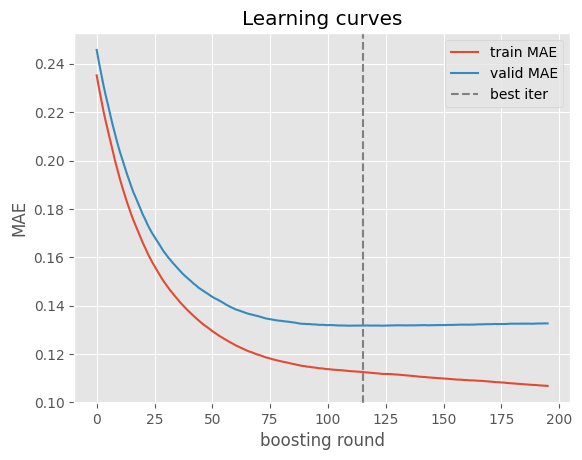

In [94]:
plt.plot(train_metric, label='train MAE')
plt.plot(valid_metric, label='valid MAE')
plt.axvline(bst.best_iteration, color='gray', linestyle='--', label='best iter')
plt.xlabel('boosting round')
plt.ylabel('MAE')
plt.legend()
plt.title('Learning curves')
plt.show()


Running xgb.cv for learning_rate=0.01 ...
[0]	train-mae:0.23959+0.00179	test-mae:0.23961+0.00279
[100]	train-mae:0.17397+0.00092	test-mae:0.17636+0.00230
[200]	train-mae:0.14581+0.00074	test-mae:0.15015+0.00232
[300]	train-mae:0.13209+0.00062	test-mae:0.13799+0.00226
[400]	train-mae:0.12472+0.00066	test-mae:0.13204+0.00223
[500]	train-mae:0.12183+0.00064	test-mae:0.13036+0.00226
[600]	train-mae:0.12053+0.00058	test-mae:0.13012+0.00226
[700]	train-mae:0.11941+0.00059	test-mae:0.13005+0.00220
[800]	train-mae:0.11833+0.00056	test-mae:0.12996+0.00217
[900]	train-mae:0.11745+0.00060	test-mae:0.13002+0.00217
[901]	train-mae:0.11744+0.00059	test-mae:0.13002+0.00218
 -> lr=0.01 best_round=802, best test MAE=0.129959

Running xgb.cv for learning_rate=0.03 ...
[0]	train-mae:0.23763+0.00176	test-mae:0.23770+0.00274
[100]	train-mae:0.13166+0.00081	test-mae:0.13742+0.00210
[200]	train-mae:0.12072+0.00065	test-mae:0.13009+0.00204
[300]	train-mae:0.11748+0.00052	test-mae:0.12994+0.00215
[358]	train-

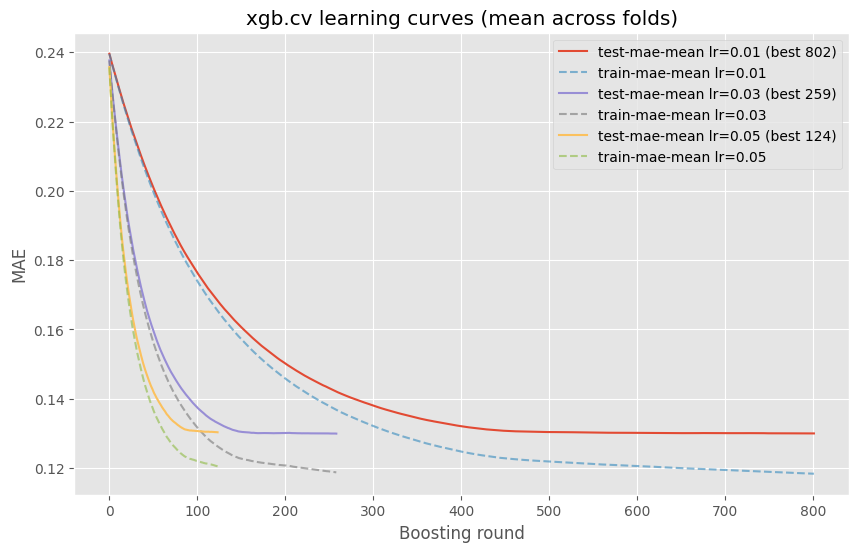

In [96]:
# Base params (modify other regularization/complexity params as you like)
base_params = {
    'objective': 'reg:squarederror',
    'eval_metric': 'mae',
    'verbosity': 1,
    'max_depth': 4,
    'min_child_weight': 5,
    'gamma': 1.0,
    'subsample': 0.75,
    'colsample_bytree': 0.7,
    'reg_alpha': 0.5,
    'reg_lambda': 2.0
}

# learning rates to try
lrs = [0.01, 0.03, 0.05]

# CV settings
nfold = 5
num_boost_round = 5000            # large number; early stopping will cut it down
early_stopping_rounds = 100
seed = 42

cv_summaries = {}  # store DataFrames & best rounds per lr

for lr in lrs:
    params = dict(base_params)
    params['learning_rate'] = lr

    print(f"\nRunning xgb.cv for learning_rate={lr} ...")
    cvresult = xgb.cv(
        params=params,
        dtrain=dtrain,
        num_boost_round=num_boost_round,
        nfold=nfold,
        early_stopping_rounds=early_stopping_rounds,
        metrics='mae',
        seed=seed,
        as_pandas=True,
        stratified=False,      # regression -> False
        verbose_eval=100
    )

    best_round = len(cvresult)  # xgb.cv returns rows up to best round
    best_test_mae = cvresult['test-mae-mean'].min()
    print(f" -> lr={lr} best_round={best_round}, best test MAE={best_test_mae:.6f}")

    cv_summaries[lr] = {'df': cvresult, 'best_round': best_round, 'best_test_mae': best_test_mae}

# Plot CV curves for each learning rate (train/test mean)
plt.figure(figsize=(10,6))
for lr, info in cv_summaries.items():
    df = info['df']
    plt.plot(df['test-mae-mean'].values, label=f"test-mae-mean lr={lr} (best {info['best_round']})")
    plt.plot(df['train-mae-mean'].values, linestyle='--', alpha=0.6, label=f"train-mae-mean lr={lr}")

plt.xlabel('Boosting round')
plt.ylabel('MAE')
plt.title('xgb.cv learning curves (mean across folds)')
plt.legend()
plt.grid(True)
plt.show()

In [97]:
# assume cv_summaries from your run and you selected lr_chosen (float)
lr_chosen = 0.01               
best_round = cv_summaries[lr_chosen]['best_round']

final_params = dict(base_params)   # base_params as used in CV
final_params['learning_rate'] = lr_chosen

bst_final = xgb.train(
    final_params,
    dtrain,
    num_boost_round=best_round,
    verbose_eval=10
)

bst_final.save_model('../models/xgb_final_from_cv.json')

In [98]:
importance_gain = bst_final.get_score(importance_type='gain')
importance_wt = bst_final.get_score(importance_type='weight')

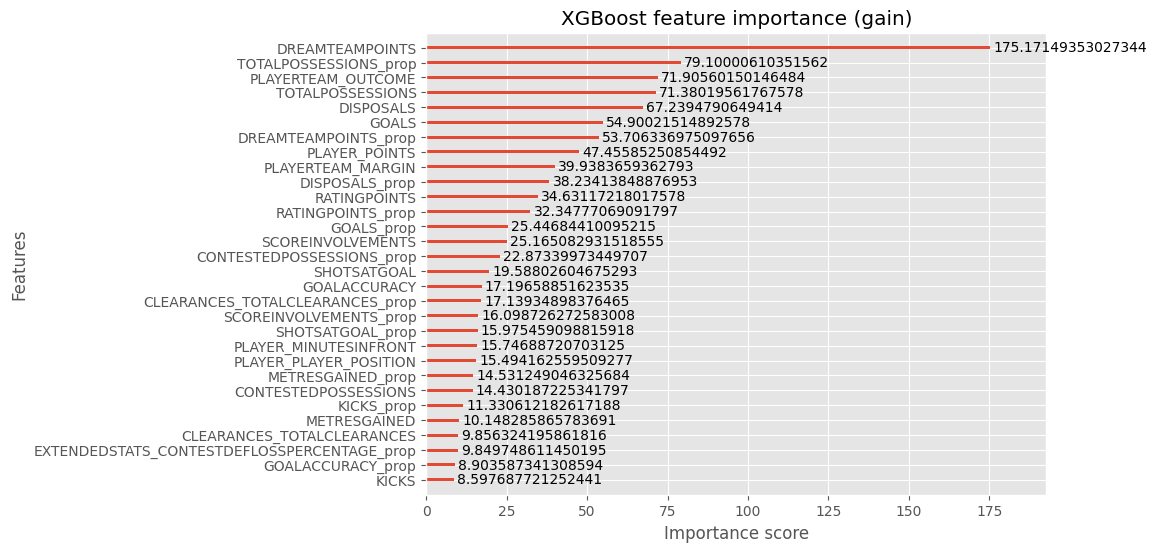

In [99]:
fig, ax = plt.subplots(figsize=(8,6))
xgb.plot_importance(bst_final, importance_type='gain', max_num_features=30, ax=ax)
ax.set_title("XGBoost feature importance (gain)")
plt.show()

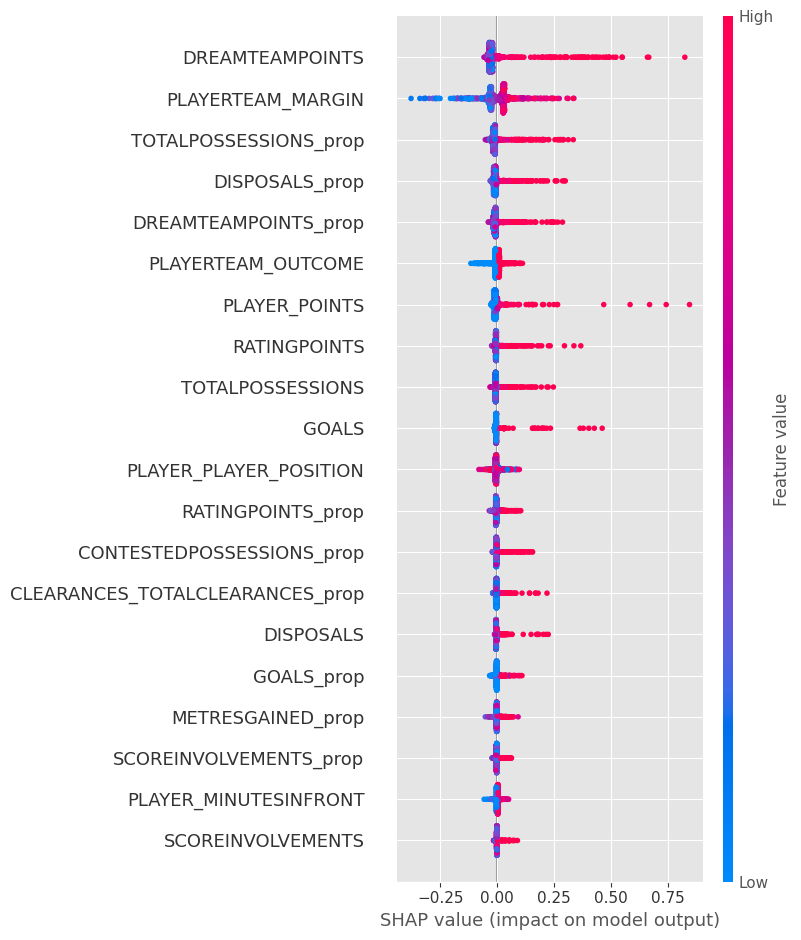

In [100]:
# copy data to avoid mutating original
X_shap = X_afl_train[feature_list].copy()
# find categorical columns (pandas 'category' dtype)
cat_cols = X_shap.select_dtypes(include=['category']).columns.tolist()
# save mappings if you want to reverse codes later
cat_mappings = {}
for c in cat_cols:
    # use codes but preserve a mapping from code -> category value
    cats = X_shap[c].cat.categories
    cat_mappings[c] = dict(enumerate(cats))
    X_shap[c] = X_shap[c].cat.codes.replace({-1: pd.NA})  # -1 is pandas code for NaN
# optionally fill any remaining NaNs in numeric columns (SHAP needs finite values)
X_shap = X_shap.fillna(0)
# sample if large
X_sample = X_shap.sample(n=min(1000, len(X_shap)), random_state=42)

# 1) Create TreeExplainer from the Booster
explainer = shap.TreeExplainer(bst_final)   # handles xgb.Booster directly

# 2) compute shap values (returns array shaped (n_samples, n_features))
shap_values = explainer.shap_values(X_sample)   # for regression this is 2D

# 3) summary plot (global)
shap.summary_plot(shap_values, X_sample, plot_type="dot")  # beeswarm

# Make 2025 Prediction

In [101]:
# 8) predict on new data (make DMatrix the same way)
dtest = xgb.DMatrix(X_afl_test[feature_list], enable_categorical=True)
y_pred = bst_final.predict(dtest) #, ntree_limit=bst.best_iteration+1)

In [102]:
brownlow_pred_series = pd.Series(y_pred,name='BROWNLOW_FLOAT_PREDICTION')
full_df_pred = pd.concat([X_afl_test, brownlow_pred_series], axis=1)

In [103]:
full_df_pred[(full_df_pred['ROUND_ROUNDNUMBER'] == 24) ].sort_values(by='BROWNLOW_FLOAT_PREDICTION', ascending=False).head(10)

,PROVIDERID,ROUND_ROUNDNUMBER,HOME_TEAM_NAME,PLAYER_PLAYER_POSITION,PLAYER_PLAYER_PLAYER_PLAYERID,GOALS,BEHINDS,KICKS,HANDBALLS,DISPOSALS,MARKS,BOUNCES,TACKLES,CONTESTEDPOSSESSIONS,UNCONTESTEDPOSSESSIONS,TOTALPOSSESSIONS,INSIDE50S,MARKSINSIDE50,CONTESTEDMARKS,HITOUTS,ONEPERCENTERS,DISPOSALEFFICIENCY,CLANGERS,FREESFOR,FREESAGAINST,DREAMTEAMPOINTS,REBOUND50S,GOALASSISTS,GOALACCURACY,RATINGPOINTS,TURNOVERS,INTERCEPTS,TACKLESINSIDE50,SHOTSATGOAL,SCOREINVOLVEMENTS,METRESGAINED,CLEARANCES_CENTRECLEARANCES,CLEARANCES_STOPPAGECLEARANCES,CLEARANCES_TOTALCLEARANCES,EXTENDEDSTATS_EFFECTIVEKICKS,EXTENDEDSTATS_KICKEFFICIENCY,EXTENDEDSTATS_KICKTOHANDBALLRATIO,EXTENDEDSTATS_EFFECTIVEDISPOSALS,EXTENDEDSTATS_MARKSONLEAD,EXTENDEDSTATS_INTERCEPTMARKS,EXTENDEDSTATS_CONTESTEDPOSSESSIONRATE,EXTENDEDSTATS_HITOUTSTOADVANTAGE,EXTENDEDSTATS_HITOUTWINPERCENTAGE,EXTENDEDSTATS_HITOUTTOADVANTAGERATE,EXTENDEDSTATS_GROUNDBALLGETS,EXTENDEDSTATS_F50GROUNDBALLGETS,EXTENDEDSTATS_SCORELAUNCHES,EXTENDEDSTATS_PRESSUREACTS,EXTENDEDSTATS_DEFHALFPRESSUREACTS,EXTENDEDSTATS_SPOILS,EXTENDEDSTATS_RUCKCONTESTS,EXTENDEDSTATS_CONTESTDEFONEONONES,EXTENDEDSTATS_CONTESTDEFLOSSES,EXTENDEDSTATS_CONTESTDEFLOSSPERCENTAGE,EXTENDEDSTATS_CONTESTOFFONEONONES,EXTENDEDSTATS_CONTESTOFFWINS,EXTENDEDSTATS_CONTESTOFFWINSPERCENTAGE,TEAM_NAME,FULL_NAME,PLAYER_POINTS,PLAYER_CAPTAIN,GAME_DATE,MATCHID,ROUND_YEAR,HOMETEAMSCORE_MINUTESINFRONT,AWAYTEAMSCORE_MINUTESINFRONT,HOMETEAMSCORE_MATCHSCORE_TOTALSCORE,AWAYTEAMSCORE_MATCHSCORE_TOTALSCORE,DATE,FIRST_NAME,SURNAME,PLAYING_FOR,BROWNLOW_VOTES,AT_HOME,PLAYERTEAMSCORE,PLAYER_MINUTESINFRONT,PLAYERTEAM_MARGIN,PLAYERTEAM_OUTCOME,GOALS_prop,BEHINDS_prop,KICKS_prop,HANDBALLS_prop,DISPOSALS_prop,MARKS_prop,BOUNCES_prop,TACKLES_prop,CONTESTEDPOSSESSIONS_prop,UNCONTESTEDPOSSESSIONS_prop,TOTALPOSSESSIONS_prop,INSIDE50S_prop,MARKSINSIDE50_prop,CONTESTEDMARKS_prop,HITOUTS_prop,ONEPERCENTERS_prop,DISPOSALEFFICIENCY_prop,CLANGERS_prop,FREESFOR_prop,FREESAGAINST_prop,DREAMTEAMPOINTS_prop,REBOUND50S_prop,GOALASSISTS_prop,GOALACCURACY_prop,RATINGPOINTS_prop,TURNOVERS_prop,INTERCEPTS_prop,TACKLESINSIDE50_prop,SHOTSATGOAL_prop,SCOREINVOLVEMENTS_prop,METRESGAINED_prop,CLEARANCES_CENTRECLEARANCES_prop,CLEARANCES_STOPPAGECLEARANCES_prop,CLEARANCES_TOTALCLEARANCES_prop,EXTENDEDSTATS_EFFECTIVEKICKS_prop,EXTENDEDSTATS_EFFECTIVEDISPOSALS_prop,EXTENDEDSTATS_MARKSONLEAD_prop,EXTENDEDSTATS_INTERCEPTMARKS_prop,EXTENDEDSTATS_CONTESTEDPOSSESSIONRATE_prop,EXTENDEDSTATS_HITOUTSTOADVANTAGE_prop,EXTENDEDSTATS_HITOUTWINPERCENTAGE_prop,EXTENDEDSTATS_HITOUTTOADVANTAGERATE_prop,EXTENDEDSTATS_GROUNDBALLGETS_prop,EXTENDEDSTATS_F50GROUNDBALLGETS_prop,EXTENDEDSTATS_SCORELAUNCHES_prop,EXTENDEDSTATS_PRESSUREACTS_prop,EXTENDEDSTATS_DEFHALFPRESSUREACTS_prop,EXTENDEDSTATS_SPOILS_prop,EXTENDEDSTATS_RUCKCONTESTS_prop,EXTENDEDSTATS_CONTESTDEFONEONONES_prop,EXTENDEDSTATS_CONTESTDEFLOSSES_prop,EXTENDEDSTATS_CONTESTDEFLOSSPERCENTAGE_prop,EXTENDEDSTATS_CONTESTOFFONEONONES_prop,EXTENDEDSTATS_CONTESTOFFWINS_prop,EXTENDEDSTATS_CONTESTOFFWINSPERCENTAGE_prop,BROWNLOW_FLOAT_PREDICTION
9484,CD_M20250142410,24,Gold Coast SUNS,R,CD_I1009199,3,0,19,15,34,3,5,0,18,15,33,5,1,0,0,2,79.4,2,0,0,114,3,1,75.0,37.1,1,6,0,4,8,634,8,4,12,12.0,63.2,1.3,27.0,1.0,0.0,54.5,0.0,0.0,0.0,12.0,2.0,4.0,10.0,9.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,Gold Coast SUNS,NOAH ANDERSON,18,False,2025-08-27,CD_M20250142410,2025,122,0,153,58,NaN,NaN,NaN,NaN,NaN,1,153,122,95,WIN,0.130435,0.000000,0.090909,0.076923,0.084158,0.034884,0.384615,0.000000,0.144000,0.055970,0.083969,0.074627,0.038462,0.0000,0.0,0.052632,0.043317,0.033898,0.000000,0.000000,0.073596,0.081081,0.058824,0.086967,0.132595,0.018519,0.098361,0.000000,0.100000,0.045714,0.089158,0.444444,0.222222,0.333333,0.077419,0.082569,0.066667,0.000000,0.072880,0.0,0.0,0.0,0.146341,0.153846,0.105263,0.049020,0.092784,0.00,0.0,0.000000,0.0,0.0,0.000000,0.0,0.0,2.626628
9165,CD_M20250142401,24,Port Adelaide,R,CD_I1006121,0,1,19,16,35,8,3,8,14,18,32,2,0,0,0,0,74.3,1,6,0,152,5,0,0.0,17.2,4,8,0,1,6,56

# Rank and score for each game

In [104]:
full_df_pred['BROWNLOW_RANK'] = (full_df_pred
                                 .groupby(['MATCHID'])['BROWNLOW_FLOAT_PREDICTION']
                                 .rank(method='min', ascending=False)) # the method just means a tie gets the lowest rank value like a tie for top both get a 1

In [105]:
rank_series = full_df_pred['BROWNLOW_RANK'].astype(float)

full_df_pred['BROWNLOW_POINTS'] = np.select(
    condlist=[rank_series == 1, rank_series == 2, rank_series == 3],
    choicelist=[3,2,1],
    default=0
).astype(int)

In [106]:
full_df_pred[(full_df_pred['ROUND_ROUNDNUMBER'] == 24) ].sort_values(by='BROWNLOW_FLOAT_PREDICTION', ascending=False).head(10)

,PROVIDERID,ROUND_ROUNDNUMBER,HOME_TEAM_NAME,PLAYER_PLAYER_POSITION,PLAYER_PLAYER_PLAYER_PLAYERID,GOALS,BEHINDS,KICKS,HANDBALLS,DISPOSALS,MARKS,BOUNCES,TACKLES,CONTESTEDPOSSESSIONS,UNCONTESTEDPOSSESSIONS,TOTALPOSSESSIONS,INSIDE50S,MARKSINSIDE50,CONTESTEDMARKS,HITOUTS,ONEPERCENTERS,DISPOSALEFFICIENCY,CLANGERS,FREESFOR,FREESAGAINST,DREAMTEAMPOINTS,REBOUND50S,GOALASSISTS,GOALACCURACY,RATINGPOINTS,TURNOVERS,INTERCEPTS,TACKLESINSIDE50,SHOTSATGOAL,SCOREINVOLVEMENTS,METRESGAINED,CLEARANCES_CENTRECLEARANCES,CLEARANCES_STOPPAGECLEARANCES,CLEARANCES_TOTALCLEARANCES,EXTENDEDSTATS_EFFECTIVEKICKS,EXTENDEDSTATS_KICKEFFICIENCY,EXTENDEDSTATS_KICKTOHANDBALLRATIO,EXTENDEDSTATS_EFFECTIVEDISPOSALS,EXTENDEDSTATS_MARKSONLEAD,EXTENDEDSTATS_INTERCEPTMARKS,EXTENDEDSTATS_CONTESTEDPOSSESSIONRATE,EXTENDEDSTATS_HITOUTSTOADVANTAGE,EXTENDEDSTATS_HITOUTWINPERCENTAGE,EXTENDEDSTATS_HITOUTTOADVANTAGERATE,EXTENDEDSTATS_GROUNDBALLGETS,EXTENDEDSTATS_F50GROUNDBALLGETS,EXTENDEDSTATS_SCORELAUNCHES,EXTENDEDSTATS_PRESSUREACTS,EXTENDEDSTATS_DEFHALFPRESSUREACTS,EXTENDEDSTATS_SPOILS,EXTENDEDSTATS_RUCKCONTESTS,EXTENDEDSTATS_CONTESTDEFONEONONES,EXTENDEDSTATS_CONTESTDEFLOSSES,EXTENDEDSTATS_CONTESTDEFLOSSPERCENTAGE,EXTENDEDSTATS_CONTESTOFFONEONONES,EXTENDEDSTATS_CONTESTOFFWINS,EXTENDEDSTATS_CONTESTOFFWINSPERCENTAGE,TEAM_NAME,FULL_NAME,PLAYER_POINTS,PLAYER_CAPTAIN,GAME_DATE,MATCHID,ROUND_YEAR,HOMETEAMSCORE_MINUTESINFRONT,AWAYTEAMSCORE_MINUTESINFRONT,HOMETEAMSCORE_MATCHSCORE_TOTALSCORE,AWAYTEAMSCORE_MATCHSCORE_TOTALSCORE,DATE,FIRST_NAME,SURNAME,PLAYING_FOR,BROWNLOW_VOTES,AT_HOME,PLAYERTEAMSCORE,PLAYER_MINUTESINFRONT,PLAYERTEAM_MARGIN,PLAYERTEAM_OUTCOME,GOALS_prop,BEHINDS_prop,KICKS_prop,HANDBALLS_prop,DISPOSALS_prop,MARKS_prop,BOUNCES_prop,TACKLES_prop,CONTESTEDPOSSESSIONS_prop,UNCONTESTEDPOSSESSIONS_prop,TOTALPOSSESSIONS_prop,INSIDE50S_prop,MARKSINSIDE50_prop,CONTESTEDMARKS_prop,HITOUTS_prop,ONEPERCENTERS_prop,DISPOSALEFFICIENCY_prop,CLANGERS_prop,FREESFOR_prop,FREESAGAINST_prop,DREAMTEAMPOINTS_prop,REBOUND50S_prop,GOALASSISTS_prop,GOALACCURACY_prop,RATINGPOINTS_prop,TURNOVERS_prop,INTERCEPTS_prop,TACKLESINSIDE50_prop,SHOTSATGOAL_prop,SCOREINVOLVEMENTS_prop,METRESGAINED_prop,CLEARANCES_CENTRECLEARANCES_prop,CLEARANCES_STOPPAGECLEARANCES_prop,CLEARANCES_TOTALCLEARANCES_prop,EXTENDEDSTATS_EFFECTIVEKICKS_prop,EXTENDEDSTATS_EFFECTIVEDISPOSALS_prop,EXTENDEDSTATS_MARKSONLEAD_prop,EXTENDEDSTATS_INTERCEPTMARKS_prop,EXTENDEDSTATS_CONTESTEDPOSSESSIONRATE_prop,EXTENDEDSTATS_HITOUTSTOADVANTAGE_prop,EXTENDEDSTATS_HITOUTWINPERCENTAGE_prop,EXTENDEDSTATS_HITOUTTOADVANTAGERATE_prop,EXTENDEDSTATS_GROUNDBALLGETS_prop,EXTENDEDSTATS_F50GROUNDBALLGETS_prop,EXTENDEDSTATS_SCORELAUNCHES_prop,EXTENDEDSTATS_PRESSUREACTS_prop,EXTENDEDSTATS_DEFHALFPRESSUREACTS_prop,EXTENDEDSTATS_SPOILS_prop,EXTENDEDSTATS_RUCKCONTESTS_prop,EXTENDEDSTATS_CONTESTDEFONEONONES_prop,EXTENDEDSTATS_CONTESTDEFLOSSES_prop,EXTENDEDSTATS_CONTESTDEFLOSSPERCENTAGE_prop,EXTENDEDSTATS_CONTESTOFFONEONONES_prop,EXTENDEDSTATS_CONTESTOFFWINS_prop,EXTENDEDSTATS_CONTESTOFFWINSPERCENTAGE_prop,BROWNLOW_FLOAT_PREDICTION,BROWNLOW_RANK,BROWNLOW_POINTS
9484,CD_M20250142410,24,Gold Coast SUNS,R,CD_I1009199,3,0,19,15,34,3,5,0,18,15,33,5,1,0,0,2,79.4,2,0,0,114,3,1,75.0,37.1,1,6,0,4,8,634,8,4,12,12.0,63.2,1.3,27.0,1.0,0.0,54.5,0.0,0.0,0.0,12.0,2.0,4.0,10.0,9.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,Gold Coast SUNS,NOAH ANDERSON,18,False,2025-08-27,CD_M20250142410,2025,122,0,153,58,NaN,NaN,NaN,NaN,NaN,1,153,122,95,WIN,0.130435,0.000000,0.090909,0.076923,0.084158,0.034884,0.384615,0.000000,0.144000,0.055970,0.083969,0.074627,0.038462,0.0000,0.0,0.052632,0.043317,0.033898,0.000000,0.000000,0.073596,0.081081,0.058824,0.086967,0.132595,0.018519,0.098361,0.000000,0.100000,0.045714,0.089158,0.444444,0.222222,0.333333,0.077419,0.082569,0.066667,0.000000,0.072880,0.0,0.0,0.0,0.146341,0.153846,0.105263,0.049020,0.092784,0.00,0.0,0.000000,0.0,0.0,0.000000,0.0,0.0,2.626628,1.0,3
9165,CD_M20250142401,24,Port Adelaide,R,CD_I1006121,0,1,19,16,35,8,3,8,14,18,32,2,0,0,0,0,74.3

In [107]:
full_df_pred.groupby(['FULL_NAME','TEAM_NAME'])['BROWNLOW_POINTS'].sum().sort_values(ascending=False).reset_index()

,FULL_NAME,TEAM_NAME,BROWNLOW_POINTS
0,NICK DAICOS,Collingwood,37
1,BAILEY SMITH,Geelong Cats,33
2,NOAH ANDERSON,Gold Coast SUNS,31
3,CALEB SERONG,Fremantle,30
4,JORDAN DAWSON,Adelaide Crows,30
...,...,...,...
664,JAMIE CRIPPS,West Coast Eagles,0
665,JAMES TUNSTILL,Brisbane Lions,0
666,JAMES TREZISE,Richmond,0
667,BO ALLAN,West Coast Eagles,0


In [108]:
# monte carlo output
mc_output_cols = ['FULL_NAME','TEAM_NAME','ROUND_ROUNDNUMBER','MATCHID','BROWNLOW_FLOAT_PREDICTION']
full_df_pred[mc_output_cols].to_csv('../result/bronwlon_mc_output_v0.csv', index=False)